#### <u>Определение положения при помощи меток</u>

###### Решение уравнений ХКУ

In [64]:
import sympy

ε = sympy.var('ε')
t, ω, ε = sympy.var('t ω_0 ε', real=True)
r_0 = sympy.var('r_x r_y r_z')
v_0 = sympy.var('v_x v_y v_z')
r = [sympy.Function('r_x'), sympy.Function('r_y'), sympy.Function('r_z')]
v = [sympy.Function('v_x'), sympy.Function('v_y'), sympy.Function('v_z')]

eqs = [sympy.Eq(r[0](t).diff(t), v[0](t)), 
       sympy.Eq(r[1](t).diff(t), v[1](t)), 
       sympy.Eq(r[2](t).diff(t), v[2](t)), 
       sympy.Eq(v[0](t).diff(t), -2*ω*v[1](t)), 
       sympy.Eq(v[1](t).diff(t), 3*ω**2*r[1](t) + 2*ω*v[0](t)), 
       sympy.Eq(v[2](t).diff(t), -ω**2*r[2](t))]

print(f"Уравнения:")
for e in eqs:
    display(e)
    
ics={r[0](0): r_0[0], r[1](0): r_0[1], r[2](0): r_0[2], 
     v[0](0): v_0[0], v[1](0): v_0[1], v[2](0): v_0[2]}

Уравнения:


Eq(Derivative(r_x(t), t), v_x(t))

Eq(Derivative(r_y(t), t), v_y(t))

Eq(Derivative(r_z(t), t), v_z(t))

Eq(Derivative(v_x(t), t), -2*ω_0*v_y(t))

Eq(Derivative(v_y(t), t), 3*ω_0**2*r_y(t) + 2*ω_0*v_x(t))

Eq(Derivative(v_z(t), t), -ω_0**2*r_z(t))

In [2]:
print(f"Решение:")
anw1 = sympy.dsolve(eqs, [r[0](t), r[1](t), r[2](t), v[0](t), v[1](t), v[2](t)], ics=ics)
for a in anw1[0:3]:
    display(a) 

Решение:


Eq(r_x(t), r_x - t*(6*r_y*ω_0 + 3*v_x) + 2*v_y*cos(t*ω_0)/ω_0 - 2*v_y/ω_0 + (6*r_y + 4*v_x/ω_0)*sin(t*ω_0))

Eq(r_y(t), 4*r_y + 2*v_x/ω_0 + v_y*sin(t*ω_0)/ω_0 - (3*r_y + 2*v_x/ω_0)*cos(t*ω_0))

Eq(r_z(t), r_z*cos(t*ω_0) + v_z*sin(t*ω_0)/ω_0)

###### Приближение $ε=tω_0\ll 1$

In [3]:
r = sympy.Matrix([
    anw1[0].rhs,
    anw1[1].rhs,
    anw1[2].rhs
])
r

Matrix([
[r_x - t*(6*r_y*ω_0 + 3*v_x) + 2*v_y*cos(t*ω_0)/ω_0 - 2*v_y/ω_0 + (6*r_y + 4*v_x/ω_0)*sin(t*ω_0)],
[                        4*r_y + 2*v_x/ω_0 + v_y*sin(t*ω_0)/ω_0 - (3*r_y + 2*v_x/ω_0)*cos(t*ω_0)],
[                                                            r_z*cos(t*ω_0) + v_z*sin(t*ω_0)/ω_0]])

In [118]:
approx_rate = 3

r_approxed = sympy.Matrix([
    sympy.series(anw1[i].rhs.subs(t,ε/ω), ε, 0, approx_rate).removeO().subs(ε,t*ω) for i in range(3)])
r_approxed

Matrix([
[                   r_x - t**2*v_y*ω_0 + t*v_x],
[r_y + t**2*ω_0**2*(3*r_y/2 + v_x/ω_0) + t*v_y],
[             -r_z*t**2*ω_0**2/2 + r_z + t*v_z]])

###### Подстановка по схеме в) $$ \vec r^0 = (1+id r / r^0) \vec r_{deploy}, \hskip20px  \dot{\vec r}^0 = v^0 \vec e_{deploy},\hskip20px \vec r_{deploy}\perp \vec e_{deploy} \hskip20px |\vec r_{deploy}|=r^0$$

In [122]:
i,dr,dv,v0,r0 = sympy.var('i dr dv v0 r0')
ex,ey,ez,rdx,rdy,rdz = sympy.var('e_x e_y e_z r^{deploy}_x r^{deploy}_y r^{deploy}_z')

# Тут типа r_deploy единичный
r_approxed = r_approxed.subs([
    (r_0[0],r0*rdx+i*dr*rdx), (r_0[1],r0*rdy+i*dr*rdy), (r_0[2],r0*rdz+i*dr*rdz),
    (v_0[0],v0*ex), (v_0[1],v0*ey), (v_0[2],v0*ez)])
r_approxed.expand().simplify()
r_approxed

Matrix([
[                                                       dr*i*r^{deploy}_x + e_x*t*v0 - e_y*t**2*v0*ω_0 + r0*r^{deploy}_x],
[dr*i*r^{deploy}_y + e_y*t*v0 + r0*r^{deploy}_y + t**2*ω_0**2*(3*dr*i*r^{deploy}_y/2 + e_x*v0/ω_0 + 3*r0*r^{deploy}_y/2)],
[                   dr*i*r^{deploy}_z + e_z*t*v0 + r0*r^{deploy}_z - t**2*ω_0**2*(dr*i*r^{deploy}_z + r0*r^{deploy}_z)/2]])

In [112]:
# r_approxed = r_approxed.subs(ez, 0).subs(rdx, 0).subs(rdy, 0)

In [124]:
r1 = r_approxed.subs(i,i-1)
r2 = r_approxed.subs(i,i)
r_12 = r2 - r1
r_12 = r_12.expand()
r_12.simplify()
# r_12 = r_12.expand()
r_12

Matrix([
[                      dr*r^{deploy}_x],
[dr*r^{deploy}_y*(3*t**2*ω_0**2 + 2)/2],
[ dr*r^{deploy}_z*(-t**2*ω_0**2 + 2)/2]])

In [114]:
Δ_4_sq2 = 1 - (r1.dot(r2))**2 / r1.dot(r1) / r2.dot(r2)
#Δ_4_sq2 = Δ_4_sq2.simplify()
#Δ_4_sq2

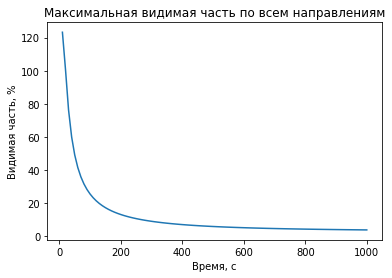

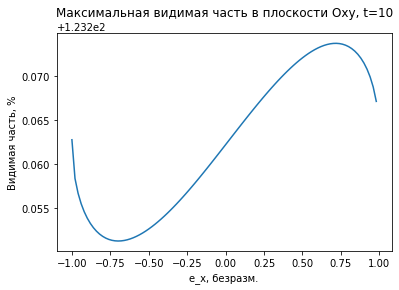

In [117]:
import matplotlib.pyplot as plt
import math

y_max, y_, t_ = [], [], 0
t_list = [10*(i+1) for i in range(100)]
e_list = [-1 + 2*i/100 for i in range(100)]

Pr1_n = Δ_4_sq2.subs([(dr, 0.005), (r0, 0.1), (v0, 0.01), (ω,0.0011),
                      (rdz, 0), (rdx, ey), (rdy, -ex)])
Pr1_n = Pr1_n.subs([(ez, 0), (ex, sympy.sqrt(1-ey**2))]).simplify()

for it in t_list:
    tmp = Pr1_n.subs(t,it)
    y = [math.sqrt(float(sympy.re(tmp.subs(ey,i)))) / 0.02 * 100 for i in e_list]
    if len(y_max) == 0 or max(y) > max(y_max):
        y_ = y
        t_ = it
    y_max.append(max(y))
    
plt.plot(t_list, y_max)
plt.title("Максимальная видимая часть по всем направлениям")
plt.xlabel("Время, с")
plt.ylabel("Видимая часть, %")
plt.show()

plt.plot(e_list, y_)
plt.title(f"Максимальная видимая часть в плоскости Oxy, t={t_}")
plt.xlabel("e_x, безразм.")
plt.ylabel("Видимая часть, %")
plt.show()

###### Подстановка по схеме б) $$ \vec r^0 = r^0 \vec e_{deploy}, \hskip20px  \dot{\vec r}^0 = v^0 \vec e_{deploy},\hskip20px t_i=i\frac{r^0}{v^0}$$

In [69]:
i,dr,dv,v0,r0 = sympy.var('i dr dv v0 r0')
ex,ey,ez = sympy.var('e_x e_y e_z')

r_approxed = r_approxed.subs([
    (r_0[0],r0*ex), (r_0[1],r0*ey), (r_0[2],r0*ez),
    (v_0[0],v0*ex), (v_0[1],v0*ey), (v_0[2],v0*ez), (t, t-i*dr/v0)])
r_approxed.expand().simplify()
r_approxed

Matrix([
[                      e_x*r0 + e_x*v0*(-dr*i/v0 - i*r0/v0 + t) - e_y*v0*ω_0*(-dr*i/v0 - i*r0/v0 + t)**2],
[e_y*r0 + e_y*v0*(-dr*i/v0 - i*r0/v0 + t) + ω_0**2*(e_x*v0/ω_0 + 3*e_y*r0/2)*(-dr*i/v0 - i*r0/v0 + t)**2],
[                -e_z*r0*ω_0**2*(-dr*i/v0 - i*r0/v0 + t)**2/2 + e_z*r0 + e_z*v0*(-dr*i/v0 - i*r0/v0 + t)]])

In [70]:
r1 = r_approxed.subs(i,0)
r2 = r_approxed.subs(i,1)
r_12 = r2 - r1
r_12 = r_12.expand()
r_12.simplify()
r_12 = r_12.expand()
r_12

Matrix([
[                                                                                                                                                  -dr**2*e_y*ω_0/v0 - dr*e_x - 2*dr*e_y*r0*ω_0/v0 + 2*dr*e_y*t*ω_0 - e_x*r0 - e_y*r0**2*ω_0/v0 + 2*e_y*r0*t*ω_0],
[dr**2*e_x*ω_0/v0 + 3*dr**2*e_y*r0*ω_0**2/(2*v0**2) + 2*dr*e_x*r0*ω_0/v0 - 2*dr*e_x*t*ω_0 + 3*dr*e_y*r0**2*ω_0**2/v0**2 - 3*dr*e_y*r0*t*ω_0**2/v0 - dr*e_y + e_x*r0**2*ω_0/v0 - 2*e_x*r0*t*ω_0 + 3*e_y*r0**3*ω_0**2/(2*v0**2) - 3*e_y*r0**2*t*ω_0**2/v0 - e_y*r0],
[                                                                                                      -dr**2*e_z*r0*ω_0**2/(2*v0**2) - dr*e_z*r0**2*ω_0**2/v0**2 + dr*e_z*r0*t*ω_0**2/v0 - dr*e_z - e_z*r0**3*ω_0**2/(2*v0**2) + e_z*r0**2*t*ω_0**2/v0 - e_z*r0]])

In [71]:
Δ_4_sq2 = 1 - (r1.dot(r2))**2 / r1.dot(r1) / r2.dot(r2)
Δ_4_sq2 = Δ_4_sq2.simplify()
Δ_4_sq2

((e_z**2*(r0*ω_0**2*(dr + r0 - t*v0)**2 + 2*v0**2*(dr - t*v0))**2 + 4*v0**2*(e_x*v0*(dr - t*v0) + e_y*ω_0*(dr + r0 - t*v0)**2)**2 + (2*e_y*v0**2*(-dr + t*v0) + ω_0*(2*e_x*v0 + 3*e_y*r0*ω_0)*(dr + r0 - t*v0)**2)**2)*(e_z**2*(-r0*t**2*ω_0**2 + 2*r0 + 2*t*v0)**2 + 4*(e_x*r0 + e_x*t*v0 - e_y*t**2*v0*ω_0)**2 + (2*e_y*r0 + 2*e_y*t*v0 + t**2*ω_0*(2*e_x*v0 + 3*e_y*r0*ω_0))**2) - (e_z**2*(r0*ω_0**2*(dr + r0 - t*v0)**2 + 2*v0**2*(dr - t*v0))*(-r0*t**2*ω_0**2 + 2*r0 + 2*t*v0) + 4*v0*(e_x*v0*(dr - t*v0) + e_y*ω_0*(dr + r0 - t*v0)**2)*(e_x*r0 + e_x*t*v0 - e_y*t**2*v0*ω_0) - (2*e_y*v0**2*(-dr + t*v0) + ω_0*(2*e_x*v0 + 3*e_y*r0*ω_0)*(dr + r0 - t*v0)**2)*(2*e_y*r0 + 2*e_y*t*v0 + t**2*ω_0*(2*e_x*v0 + 3*e_y*r0*ω_0)))**2)/((e_z**2*(r0*ω_0**2*(dr + r0 - t*v0)**2 + 2*v0**2*(dr - t*v0))**2 + 4*v0**2*(e_x*v0*(dr - t*v0) + e_y*ω_0*(dr + r0 - t*v0)**2)**2 + (2*e_y*v0**2*(-dr + t*v0) + ω_0*(2*e_x*v0 + 3*e_y*r0*ω_0)*(dr + r0 - t*v0)**2)**2)*(e_z**2*(-r0*t**2*ω_0**2 + 2*r0 + 2*t*v0)**2 + 4*(e_x*r0 + e_x*t*v0 - e_

**попробуй** $e_x=-\sqrt{1-e_y^2}$

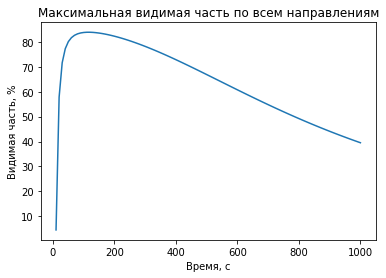

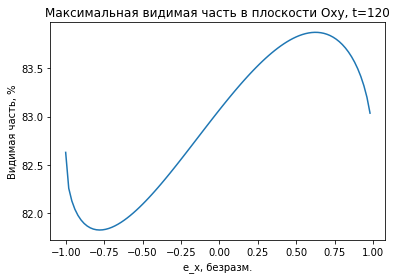

In [78]:
import matplotlib.pyplot as plt
import math

y_max, y_, t_ = [], [], 0н
t_list = [10*(i+1) for i in range(100)]
e_list = [-1 + 2*i/100 for i in range(100)]
Pr1_n = Δ_4_sq2.subs([(dr, 0.005), (r0, 0.15), (v0, 0.01), (ω,0.0011)])
Pr1_n = Pr1_n.subs([(ez, 0), (ex, sympy.sqrt(1-ey**2))]).simplify()

for it in t_list:
    tmp = Pr1_n.subs(t,it)
    y = [math.sqrt(float(sympy.re(tmp.subs(ey,i)))) / 0.02 * 100 for i in e_list]
    if len(y_max) == 0 or max(y) > max(y_max):
        y_ = y
        t_ = it
    y_max.append(max(y))
    
plt.plot(t_list, y_max)
plt.title("Максимальная видимая часть по всем направлениям")
plt.xlabel("Время, с")
plt.ylabel("Видимая часть, %")
plt.show()

plt.plot(e_list, y_)
plt.title(f"Максимальная видимая часть в плоскости Oxy, t={t_}")
plt.xlabel("e_x, безразм.")
plt.ylabel("Видимая часть, %")
plt.show()

In [76]:
e = sympy.Matrix([ex,ey,ez])
Pr_vec = r2 - r1 - e.dot(r2-r1)*e
Pr2 = (Pr_vec.dot(Pr_vec)).simplify()

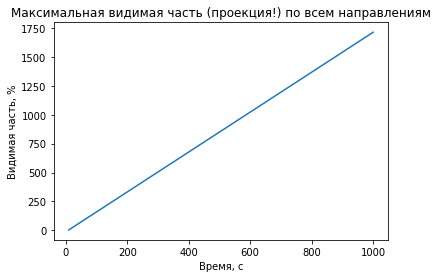

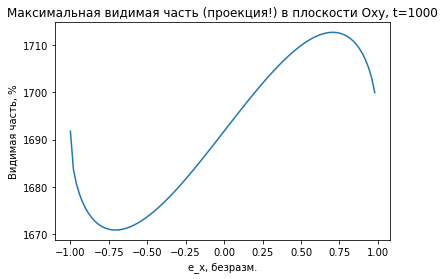

In [79]:
import matplotlib.pyplot as plt
import math

y_max, y_, t_ = [], [], 0
t_list = [10*(i+1) for i in range(100)]
e_list = [-1 + 2*i/100 for i in range(100)]
Pr1_n = Pr2.subs([(dr, 0.005), (r0, 0.15), (v0, 0.01), (ω,0.0011)])
Pr1_n = Pr1_n.subs([(ez, 0), (ex, sympy.sqrt(1-ey**2))]).simplify()

for it in t_list:
    tmp = Pr1_n.subs(t,it)
    y = [math.sqrt(float(sympy.re(tmp.subs(ey,i)))) / 0.02 * 100 for i in e_list]
    if len(y_max) == 0 or max(y) > max(y_max):
        y_ = y
        t_ = it
    y_max.append(max(y))
    
plt.plot(t_list, y_max)
plt.title("Максимальная видимая часть (проекция!) по всем направлениям")
plt.xlabel("Время, с")
plt.ylabel("Видимая часть, %")
plt.show()

plt.plot(e_list, y_)
plt.title(f"Максимальная видимая часть (проекция!) в плоскости Oxy, t={t_}")
plt.xlabel("e_x, безразм.")
plt.ylabel("Видимая часть, %")
plt.show()

###### Подстановка по схеме а) $\vec e_{deploy}=\frac{\vec r^0}{|\vec r^0|}=\frac{\dot{\vec r}^0}{|\dot{\vec r}^0|}=\frac{d\vec r}{|d\vec r|}=\frac{d\vec v}{|d\vec v|}$

$|d\vec r|=dr, \hskip 20px |d\vec v|=dv, \hskip 20px |\vec r^0|=r_0, \hskip 20px  |\dot{\vec r}^0|=v_0.$

In [11]:
i,dr,dv,v0,r0 = sympy.var('i dr dv v0 r0')
ex,ey,ez = sympy.var('e_x e_y e_z')

r_approxed = r_approxed.subs([
    (r_0[0],r0*ex+i*dr*ex), (r_0[1],r0*ey+i*dr*ey), (r_0[2],r0*ez+i*dr*ez),
    (v_0[0],v0*ex+i*dv*ex), (v_0[1],v0*ey+i*dv*ey), (v_0[2],v0*ez+i*dv*ez)])
r_approxed.expand().simplify()
r_approxed

Matrix([
[dr*e_x*i + e_x*r0 + ε*(dv*e_x*i + e_x*v0)/ω_0],
[dr*e_y*i + e_y*r0 + ε*(dv*e_y*i + e_y*v0)/ω_0],
[dr*e_z*i + e_z*r0 + ε*(dv*e_z*i + e_z*v0)/ω_0]])

In [35]:
r = r.subs([
    (r_0[0],r0*ex+i*dr*ex), (r_0[1],r0*ey+i*dr*ey), (r_0[2],r0*ez+i*dr*ez),
    (v_0[0],v0*ex+i*dv*ex), (v_0[1],v0*ey+i*dv*ey), (v_0[2],v0*ez+i*dv*ez)])
r.expand().simplify()
r1 = r.subs(i,i-1)
r2 = r.subs(i,i)
r_1_2 = r2 - r1
r_1_2.simplify()
r_1_2

Matrix([
[dr*e_x - 6*dr*e_y*t*ω_0 + 6*dr*e_y*sin(t*ω_0) - 3*dv*e_x*t + 4*dv*e_x*sin(t*ω_0)/ω_0 + 2*dv*e_y*cos(t*ω_0)/ω_0 - 2*dv*e_y/ω_0],
[                           (-3*dr*e_y*ω_0*cos(t*ω_0) + 4*dr*e_y*ω_0 - 2*dv*e_x*cos(t*ω_0) + 2*dv*e_x + dv*e_y*sin(t*ω_0))/ω_0],
[                                                                                  e_z*(dr*ω_0*cos(t*ω_0) + dv*sin(t*ω_0))/ω_0]])

In [45]:
approx_rate = 3
r_1_2_approxed = sympy.Matrix([
    sympy.series(r_1_2[i].subs(t,ε/ω), ε, 0, approx_rate).removeO().subs(ε,t*ω) for i in range(3)
])
r_1_2_approxed

Matrix([
[                      dr*e_x + dv*e_x*t - dv*e_y*t**2*ω_0],
[dr*e_y + dv*e_y*t + t**2*ω_0**2*(3*dr*e_y/2 + dv*e_x/ω_0)],
[                -dr*e_z*t**2*ω_0**2/2 + dr*e_z + dv*e_z*t]])

Проекция как мера видимой части ДКА:

In [51]:
e = sympy.Matrix([ex,ey,ez])
Pr = r_1_2_approxed - r_1_2_approxed.dot(e)*e
Pr2 = Pr.dot(Pr)
Pr2 = Pr2.simplify()
Pr2

e_z**2*(dr*t**2*ω_0**2 - 2*dr - 2*dv*t + 2*e_x*(dr*e_x + dv*e_x*t - dv*e_y*t**2*ω_0) + e_y*(2*dr*e_y + 2*dv*e_y*t + t**2*ω_0*(3*dr*e_y*ω_0 + 2*dv*e_x)) + e_z**2*(-dr*t**2*ω_0**2 + 2*dr + 2*dv*t))**2/4 + (2*dr*e_x + 2*dv*e_x*t - 2*dv*e_y*t**2*ω_0 - e_x*(2*e_x*(dr*e_x + dv*e_x*t - dv*e_y*t**2*ω_0) + e_y*(2*dr*e_y + 2*dv*e_y*t + t**2*ω_0*(3*dr*e_y*ω_0 + 2*dv*e_x)) + e_z**2*(-dr*t**2*ω_0**2 + 2*dr + 2*dv*t)))**2/4 + (2*dr*e_y + 2*dv*e_y*t - e_y*(2*e_x*(dr*e_x + dv*e_x*t - dv*e_y*t**2*ω_0) + e_y*(2*dr*e_y + 2*dv*e_y*t + t**2*ω_0*(3*dr*e_y*ω_0 + 2*dv*e_x)) + e_z**2*(-dr*t**2*ω_0**2 + 2*dr + 2*dv*t)) + t**2*ω_0*(3*dr*e_y*ω_0 + 2*dv*e_x))**2/4

In [86]:
tmp = Pr.subs([(dv, -2*dr*ω*ey/ex)]) / dr
tmp.simplify()
tmp.expand()

Matrix([
[          -e_x**3 + 2*e_x**2*e_y*t*ω_0 - 3*e_x*e_y**2*t**2*ω_0**2/2 - e_x*e_y**2 + e_x*e_z**2*t**2*ω_0**2/2 - e_x*e_z**2 + e_x + 2*e_y**3*t*ω_0 + 2*e_y*e_z**2*t*ω_0 - 2*e_y*t*ω_0 + 2*e_y**2*t**2*ω_0**2/e_x],
[   -e_x**2*e_y + 2*e_x*e_y**2*t*ω_0 - 3*e_y**3*t**2*ω_0**2/2 - e_y**3 + e_y*e_z**2*t**2*ω_0**2/2 - e_y*e_z**2 - e_y*t**2*ω_0**2/2 + e_y + 2*e_y**4*t*ω_0/e_x + 2*e_y**2*e_z**2*t*ω_0/e_x - 2*e_y**2*t*ω_0/e_x],
[-e_x**2*e_z + 2*e_x*e_y*e_z*t*ω_0 - 3*e_y**2*e_z*t**2*ω_0**2/2 - e_y**2*e_z + e_z**3*t**2*ω_0**2/2 - e_z**3 - e_z*t**2*ω_0**2/2 + e_z + 2*e_y**3*e_z*t*ω_0/e_x + 2*e_y*e_z**3*t*ω_0/e_x - 2*e_y*e_z*t*ω_0/e_x]])

In [165]:
Pr2_ = Pr2.subs([(dv, -2*dr*ω*ey/ex)]) / dr**2
# Pr2_ = Pr2
Pr2_ = Pr2_.simplify()
Pr2_

(e_y**2*(2*e_x*(e_x*(e_x - 2*e_y*t*ω_0) + 2*e_y**2*t**2*ω_0**2) + e_x*(t**2*ω_0**2 - 2) - e_y**2*(e_x*(t**2*ω_0**2 - 2) + 4*e_y*t*ω_0) + 4*e_y*t*ω_0 - e_z**2*(e_x*(t**2*ω_0**2 - 2) + 4*e_y*t*ω_0))**2 + e_z**2*(e_x*(2*e_x*(e_x - 2*e_y*t*ω_0) + 4*e_y**2*t**2*ω_0**2 + t**2*ω_0**2 - 2) - e_y**2*(e_x*(t**2*ω_0**2 - 2) + 4*e_y*t*ω_0) + 4*e_y*t*ω_0 - e_z**2*(e_x*(t**2*ω_0**2 - 2) + 4*e_y*t*ω_0))**2 + (e_x*(-2*e_x*(e_x*(e_x - 2*e_y*t*ω_0) + 2*e_y**2*t**2*ω_0**2) + 2*e_x + e_y**2*(e_x*(t**2*ω_0**2 - 2) + 4*e_y*t*ω_0) - 4*e_y*t*ω_0 + e_z**2*(e_x*(t**2*ω_0**2 - 2) + 4*e_y*t*ω_0)) + 4*e_y**2*t**2*ω_0**2)**2)/(4*e_x**2)

In [160]:
Pr2_1 = Pr2_.subs(ez, sympy.sqrt(1-ex**2-ey**2)).simplify()
Pr2_1 = Pr2_1.subs([(dr, 0.005), (dv, 0.01), (t,100), (ω,0.0011)])
Pr2_1

-9.150625e-10*e_x**4 - 7.3205e-9*e_x**2*e_y**2 + 0.0121000009150625*e_x**2 + 1.9965e-5*e_x*e_y - 1.4641e-8*e_y**4 + 0.012100014641*e_y**2

In [151]:
Pr2_1 = Pr2_.subs([(ez, 0), (ey, sympy.sqrt(1-ex**2))]).simplify()
display(Pr2_1)
eq = sympy.Eq(Pr2_1.diff(ex),0)
ans = sympy.solve(eq, ex)
for a in ans:
    display(a)
    print(f"[{float(sympy.re(a))}]+i[{float(sympy.im(a))}] = {a}")

t**4*ω_0**2*(-9*dr**2*e_x**4*ω_0**2 + 9*dr**2*e_x**2*ω_0**2 + 12*dr*dv*e_x*ω_0*sqrt(1 - e_x**2) + 4*dv**2)/(4*dr**2)

-sqrt(2)/2

[-0.7071067811865476]+i[0.0] = -sqrt(2)/2


sqrt(2)/2

[0.7071067811865476]+i[0.0] = sqrt(2)/2


-sqrt(1/2 - sqrt((3*dr*ω_0 - 4*dv)*(3*dr*ω_0 + 4*dv))/(6*dr*ω_0))

TypeError: Cannot convert expression to float

In [152]:
a

-sqrt(1/2 - sqrt((3*dr*ω_0 - 4*dv)*(3*dr*ω_0 + 4*dv))/(6*dr*ω_0))

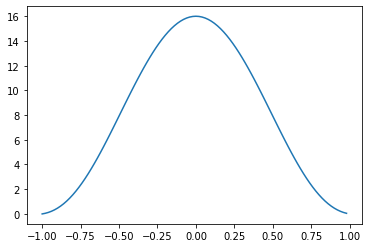

In [141]:
import matplotlib.pyplot as plt
tmp = -9*ex**6 + 33*ex**4 - 40*ex**2 + 16
ex_list = [-1 + 2*i/100 for i in range(100)]
plt.plot(ex_list, [float(tmp.subs(ex,i)) for i in ex_list])
plt.show()

In [166]:
Pr2_1 = Pr2_.subs([(ez, 0), (ex, sympy.sqrt(1-ey**2))]).simplify()
display(Pr2_1)
eq = sympy.Eq(Pr2_1.diff(ey),0)
ans = sympy.solve(eq, ey)
for a in ans:
    display(a)
    print(f"[{float(sympy.re(a))}]+i[{float(sympy.im(a))}] = {a}")

e_y**2*t**4*ω_0**4*(-9*e_y**4 - 6*e_y**2 - 1)/(4*(e_y**2 - 1))

0

[0.0]+i[0.0] = 0


-sqrt(3)*I/3

[0.0]+i[-0.5773502691896257] = -sqrt(3)*I/3


...

[0.0]+i[0.3223547173998956] = sqrt(3/4 - sqrt(105)/12)


-sqrt(3/4 + sqrt(105)/12)

[-1.2664566963895634]+i[0.0] = -sqrt(3/4 + sqrt(105)/12)


sqrt(3/4 + sqrt(105)/12)

[1.2664566963895634]+i[0.0] = sqrt(3/4 + sqrt(105)/12)


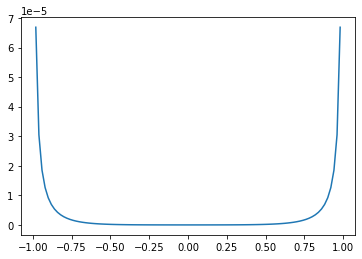

In [167]:
import matplotlib.pyplot as plt

Pr2_n = Pr2_.subs(t,100).subs(ω,0.0011).subs([(ez, 0), (ex, sympy.sqrt(1-ey**2))]).simplify()
e_list = [-1 + 2*i/100 for i in range(100)]
plt.plot(e_list, [float(sympy.re(Pr2_n.subs(ey,i))) * 0.005 for i in e_list])
plt.show()

In [168]:
2*0.0011*0.005

1.1000000000000001e-05

In [126]:
sympy.re(Pr2_.subs(ey,i).simplify())

-0.00824776333333066

In [88]:
# Pr2_ = Pr2_.subs(ez, 0))
Pr2_ = Pr2_.subs([(ez, 0), (ey, sympy.sqrt(1-ex**2))])
Pr2_ = Pr2_.simplify()
Pr2_

t**4*ω_0**4*(-9*e_x**6 + 33*e_x**4 - 40*e_x**2 + 16)/(4*e_x**2)

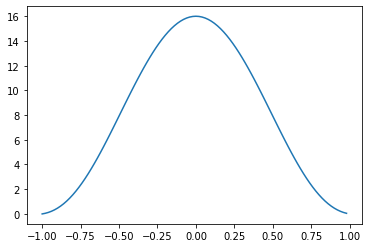

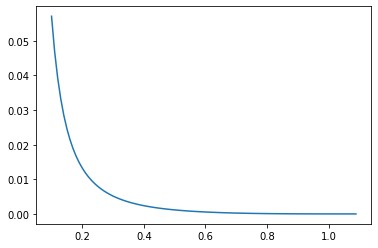

In [100]:
import matplotlib.pyplot as plt

Pr2_1 = Pr2_.subs(t,100).subs(ω,0.0011)
ex_list = [0.1 + (1-0.001)*i/100 for i in range(100)]
plt.plot(ex_list, [float(Pr2_1.subs(ex,i)) for i in ex_list])
plt.show()

In [97]:
Pr2_1.subs(ex,0.00001)

5856399.99853590

In [79]:
Pr2_1.subs(ex,i)

9.150625e-6*(-432*dr**2 + 288*dr - 48)/dr

In [72]:
# Поиск экстремумов

Pr2_.diff(ex).simplify()

t**4*ω_0**4*(-18*dr**2*e_x**6 + 9*dr**2*e_x**4 + 24*dr*e_x**4 - 16)/(2*dr*e_x**3)

In [32]:
r1 = r_approxed.subs(i,i-1)
r2 = r_approxed.subs(i,i)

r12 = r1[0]**2 + r1[1]**2 + r1[2]**2
r12 = r12.simplify()
r22 = r2[0]**2 + r2[1]**2 + r2[2]**2
r22 = r22.simplify()

r2

Matrix([
[dr*e_x*i + e_x*r0 + ε*(dv*e_x*i + e_x*v0)/ω_0],
[dr*e_y*i + e_y*r0 + ε*(dv*e_y*i + e_y*v0)/ω_0],
[dr*e_z*i + e_z*r0 + ε*(dv*e_z*i + e_z*v0)/ω_0]])

In [166]:
cos_a_num = r_approxed.subs(i,1).dot(r_approxed.subs(i,0))
cos_a_num = cos_a_num.expand().simplify()
cos_a_num

(r0*w_0**2*(dr*e_x**2 + dr*e_y**2 + dr*e_z**2 + e_x**2*r0 + e_y**2*r0 + e_z**2*r0) + v0*ε**2*(dv*e_x**2 + dv*e_y**2 + dv*e_z**2 + e_x**2*v0 + e_y**2*v0 + e_z**2*v0) + w_0*ε*(dr*e_x**2*v0 + dr*e_y**2*v0 + dr*e_z**2*v0 + dv*e_x**2*r0 + dv*e_y**2*r0 + dv*e_z**2*r0 + 2*e_x**2*r0*v0 + 2*e_y**2*r0*v0 + 2*e_z**2*r0*v0))/w_0**2

In [13]:
r1 = r_approxed.subs(i,i-1)
r2 = r_approxed.subs(i,i)

r12 = r1[0]**2 + r1[1]**2 + r1[2]**2
r12 = r12.simplify()
r22 = r2[0]**2 + r2[1]**2 + r2[2]**2
r22 = r22.simplify()
r12

(ε*(dv*(i - 1) + v0) + ω_0*(dr*(i - 1) + r0))**2*(e_x**2 + e_y**2 + e_z**2)/ω_0**2

In [172]:
cos_a_num = r_approxed.subs(i,i).dot(r_approxed.subs(i,i-1))
cos_a_num = cos_a_num.expand().simplify()
cos_a_num

(w_0**2*(dr**2*e_x**2*i**2 - dr**2*e_x**2*i + dr**2*e_y**2*i**2 - dr**2*e_y**2*i + dr**2*e_z**2*i**2 - dr**2*e_z**2*i + 2*dr*e_x**2*i*r0 - dr*e_x**2*r0 + 2*dr*e_y**2*i*r0 - dr*e_y**2*r0 + 2*dr*e_z**2*i*r0 - dr*e_z**2*r0 + e_x**2*r0**2 + e_y**2*r0**2 + e_z**2*r0**2) + w_0*ε*(2*dr*dv*e_x**2*i**2 - 2*dr*dv*e_x**2*i + 2*dr*dv*e_y**2*i**2 - 2*dr*dv*e_y**2*i + 2*dr*dv*e_z**2*i**2 - 2*dr*dv*e_z**2*i + 2*dr*e_x**2*i*v0 - dr*e_x**2*v0 + 2*dr*e_y**2*i*v0 - dr*e_y**2*v0 + 2*dr*e_z**2*i*v0 - dr*e_z**2*v0 + 2*dv*e_x**2*i*r0 - dv*e_x**2*r0 + 2*dv*e_y**2*i*r0 - dv*e_y**2*r0 + 2*dv*e_z**2*i*r0 - dv*e_z**2*r0 + 2*e_x**2*r0*v0 + 2*e_y**2*r0*v0 + 2*e_z**2*r0*v0) + ε**2*(dv**2*e_x**2*i**2 - dv**2*e_x**2*i + dv**2*e_y**2*i**2 - dv**2*e_y**2*i + dv**2*e_z**2*i**2 - dv**2*e_z**2*i + 2*dv*e_x**2*i*v0 - dv*e_x**2*v0 + 2*dv*e_y**2*i*v0 - dv*e_y**2*v0 + 2*dv*e_z**2*i*v0 - dv*e_z**2*v0 + e_x**2*v0**2 + e_y**2*v0**2 + e_z**2*v0**2))/w_0**2

Без учёта поворота: $$\Delta^2_i = r_i^2 - \frac{\left(\vec r_i,\vec r_{i-1} \right)^2}{r_{i-1}^2} $$

In [173]:
Δ2 = r22 - cos_a_num**2/r12
Δ2 = Δ2.simplify()
Δ2

0

C учётом поворота: $$\Delta^2_i = \frac{r_i^2}{\left(\vec r_i,\vec e_{toward} \right)^2} \left( r_i^2 - \frac{\left(\vec r_i,\vec r_{i-1} \right)^2}{r_{i-1}^2} \right) $$

Подкоренное выражение с камерой: $$1-\frac{\left[\left(\vec r_i,\vec r_{i-1} \right) - \left(\vec r_i+\vec r_{i-1},\vec r_{cam} \right)  \right]^2}{r_{i}^2 r_{i-1}^2}=1-\frac{\left[a_1 - a_2 \right]^2}{r_{i}^2 r_{i-1}^2}$$

In [22]:
rcam = sympy.Matrix(sympy.var('x_c y_c z_c'))
r1 = r_approxed.subs(i,i-1)
r2 = r_approxed.subs(i,i)
r12 = r1[0]**2 + r1[1]**2 + r1[2]**2
r12 = r12.simplify()
r22 = r2[0]**2 + r2[1]**2 + r2[2]**2
r22 = r22.simplify()
a1 = r1.dot(r2).simplify()
a2 = (r1+r2).dot(rcam).simplify()
a12 = ((a1 - a2).simplify())**2

*надо хитрить*

In [28]:
tmp = r12*r22 - (r1.dot(r2))**2
tmp = tmp.simplify()
tmp

0

In [25]:
Δ_sq = 1 - a12/r12/r22
# Δ_sq = Δ_sq.simplify()
Δ_sq

1 - (-ω_0*(e_x*x_c + e_y*y_c + e_z*z_c)*(ε*(dv*i + v0) + ε*(dv*(i - 1) + v0) + ω_0*(dr*i + dr*(i - 1) + 2*r0)) + (ε*(dv*i + v0) + ω_0*(dr*i + r0))*(ε*(dv*(i - 1) + v0) + ω_0*(dr*(i - 1) + r0))*(e_x**2 + e_y**2 + e_z**2))**2/((ε*(dv*i + v0) + ω_0*(dr*i + r0))**2*(ε*(dv*(i - 1) + v0) + ω_0*(dr*(i - 1) + r0))**2*(e_x**2 + e_y**2 + e_z**2)**2)

Максимальная видимая часть Δ=37.6% | t=50c
Максимальная видимая часть Δ=31.6% | t=100c
Максимальная видимая часть Δ=28.6% | t=150c


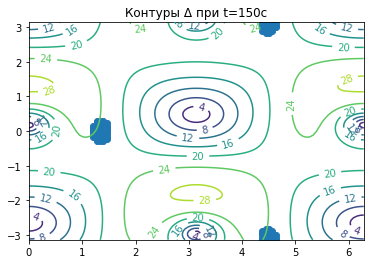

In [66]:
import matplotlib.pyplot as plt
import numpy as np
# import seaborn as sns
from math import sin, cos, sqrt, pi

ω = 0.0011

def LOS(t, rx, ry, rz, vx, vy, vz, camx, camy, camz):
    x = rx - 2*vy/ω - (6*ry*ω + 3*vx)*t + 2*vy/ω*cos(ω*t) + (6*ry + 4*vx/ω)*sin(ω*t)
    y = 4*ry + 2*vx/ω + vy/ω*sin(ω*t) - (3*ry + 2*vx/ω)*cos(ω*t)
    z = rz*cos(ω*t) + vz/ω*sin(ω*t)
    return x-camx, y-camy, z-camz

def Δ(t, i, φ, θ, dr, dv, v0, rx, ry, rz, camx, camy, camz):
    ex = cos(θ)*cos(φ)
    ey = cos(θ)*sin(φ)
    ez = sin(θ)
    j = i-1
    LOS1 = LOS(t=t, camx=camx, camy=camy, camz=camz,
               rx=rx+j*dr*ex,
               ry=ry+j*dr*ey,
               rz=rz+j*dr*ez,
               vx=v0*ex+j*dv*ex,
               vy=v0*ey+j*dv*ey,
               vz=v0*ez+j*dv*ez)
    j = i
    LOS2 = LOS(t=t, camx=camx, camy=camy, camz=camz,
               rx=rx+j*dr*ex,
               ry=ry+j*dr*ey,
               rz=rz+j*dr*ez,
               vx=v0*ex+j*dv*ex,
               vy=v0*ey+j*dv*ey,
               vz=v0*ez+j*dv*ez)
    cos_a2 = (LOS1[0]*LOS2[0] + LOS1[1]*LOS2[1] + LOS1[2]*LOS2[2])**2 / \
             (LOS1[0]**2 + LOS1[1]**2 + LOS1[2]**2) / \
             (LOS2[0]**2 + LOS2[1]**2 + LOS2[2]**2)
    return sqrt(LOS2[0]**2 + LOS2[1]**2 + LOS2[2]**2) * sqrt(1 - cos_a2)

def Δ_distribution():
    Δs = [[0 for _ in range(N)] for _ in range(N)]
    for iφ, φ in enumerate(φ_list):
        for iθ, θ in enumerate(θ_list):
            ex = cos(θ)*cos(φ)
            ey = cos(θ)*sin(φ)
            ez = sin(θ)
            rx = 0.15 * ex
            ry = 0.15 * ey
            rz = 0.15 * ez
            Δs[iφ][iθ] = Δ(t, i, φ, θ, dr, dv, v0, rx, ry, rz, camx, camy, camz) / markerSize * 100
    return Δs

N = 100
φ_list = [0+2*pi*j/(N-1) for j in range(N)]
θ_list = [-pi+2*pi*j/(N-1) for j in range(N)]

for t in [50,100,150]:
    # camx, camy, camz = 0,0,0
    camx, camy, camz = 0.14,0.05,0
    i = 1
    v0 = 0.001;
    dv = 0.000;
    dr = 0.01;
    markerSize = 0.02

    
    Δs = np.array(Δ_distribution())
    max_index = np.where(Δs>(np.max(Δs)*0.99))

    Δs_flat = [item for sublist in Δs for item in sublist]
    print(f"Максимальная видимая часть Δ={np.max(Δs):.1f}% | t={t}c")

φ_list = np.array(φ_list)
θ_list = np.array(θ_list)
CS = plt.contour(φ_list, θ_list, Δs)
plt.clabel(CS, fontsize=10)
plt.title(f'Контуры Δ при t={t}c')
plt.scatter(φ_list[max_index[0]], θ_list[max_index[1]])
plt.show()